In [1]:
import import_ipynb
import api
import matplotlib.pyplot as plt

<class 'pandas.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 15 columns):
 #   Column                                                Non-Null Count  Dtype         
---  ------                                                --------------  -----         
 0   date                                                  1776 non-null   datetime64[us]
 1   subways_total_estimated_ridership                     1776 non-null   int64         
 2   subways_of_comparable_pre_pandemic_day                1776 non-null   float64       
 3   buses_total_estimated_ridersip                        1776 non-null   int64         
 4   buses_of_comparable_pre_pandemic_day                  1776 non-null   float64       
 5   lirr_total_estimated_ridership                        1776 non-null   int64         
 6   lirr_of_comparable_pre_pandemic_day                   1776 non-null   float64       
 7   metro_north_total_estimated_ridership                 1776 non-null   int64         
 8  

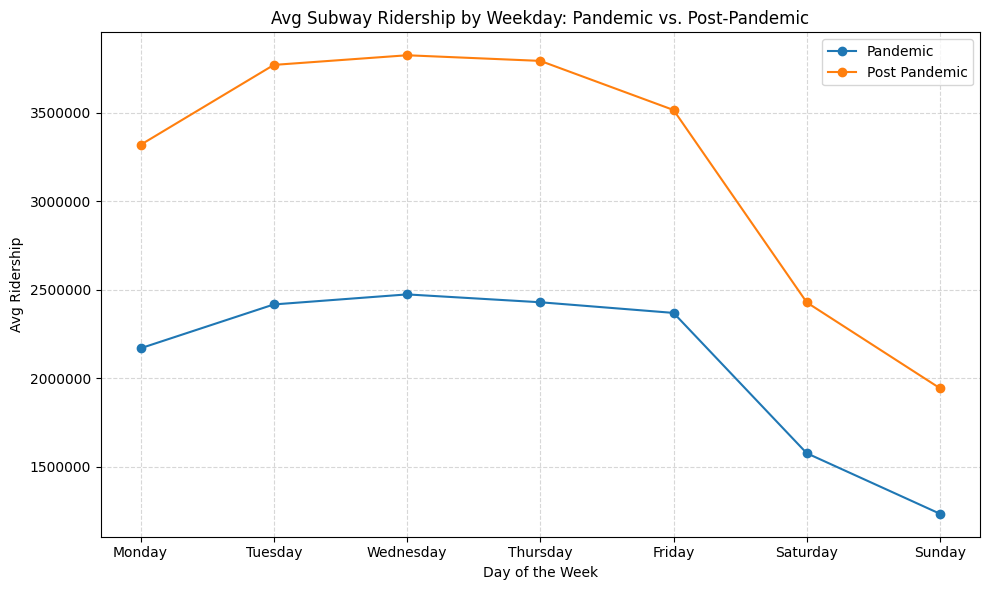

In [4]:
# I need to understand our subway ridership during and after the pandemic
# Can we predict how ridership will be affected if we have to go through a hantavirus pandemic
# Were holidays/special events resilient in terms of subway ridership throughout the pandemic, if so, which holiday/event? 

# Compare ridership from mid pandemic and post pandemic to see if there was is a dropoff
# Compare bridge and tunnel traffic pre and post pandemic
# Is there a correlation between bridge traffic and subway traffic pre and post pandemic?


df = api.df


pandemic_dates_mask = (df["date"] > "2020-03-12") & (df["date"] < "2023-03-06")
post_pandemic_mask = df['date'] > "2023-03-06"
df['day'] = df['date'].dt.day_name()
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(10, 6))

ax.yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.get_major_formatter().set_useOffset(False)

pandemic_data = df[pandemic_dates_mask]
post_pandemic_data = df[post_pandemic_mask]


grouped_pandemic_data = pandemic_data.groupby("day")["subways_total_estimated_ridership"].mean().reindex(week_order)
grouped_post_pandemic_data = post_pandemic_data.groupby("day")["subways_total_estimated_ridership"].mean().reindex(week_order)

grouped_pandemic_data.plot(kind="line", marker='o',ax=ax, figsize=(10, 6), label="Pandemic")
grouped_post_pandemic_data.plot(kind="line", marker='o',ax=ax, figsize=(10, 6), label="Post Pandemic")

plt.title("Avg Subway Ridership by Weekday: Pandemic vs. Post-Pandemic")
plt.xlabel("Day of the Week")
plt.ylabel("Avg Ridership")
plt.legend() 
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()




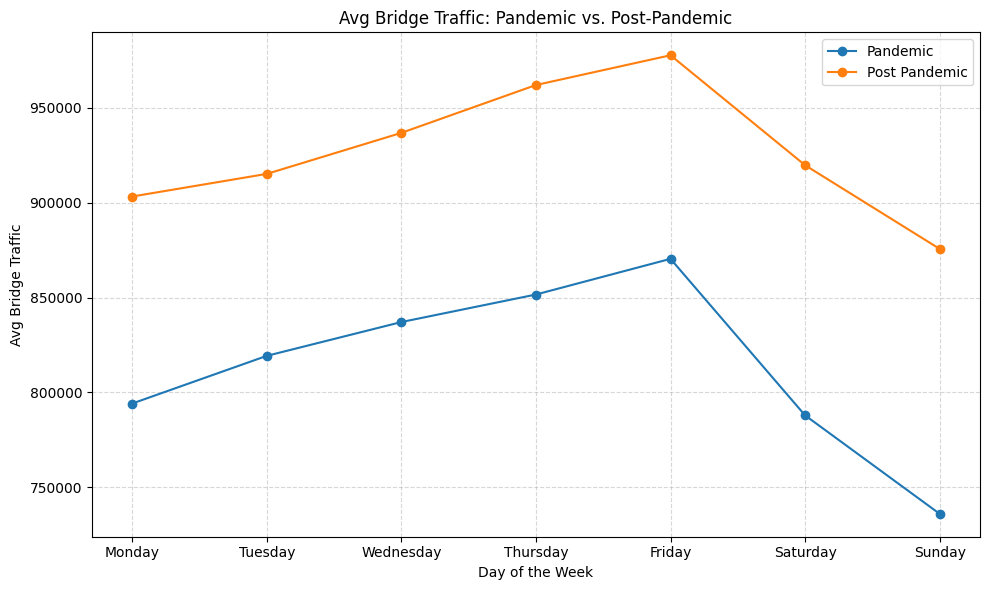

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.get_major_formatter().set_useOffset(False)


grouped_pandemic_data = pandemic_data.groupby("day")["bridges_and_tunnels_total_traffic"].mean().reindex(week_order)
grouped_post_pandemic_data = post_pandemic_data.groupby("day")["bridges_and_tunnels_total_traffic"].mean().reindex(week_order)

grouped_pandemic_data.plot(kind="line", marker='o',ax=ax, figsize=(10, 6), label="Pandemic")
grouped_post_pandemic_data.plot(kind="line", marker='o',ax=ax, figsize=(10, 6), label="Post Pandemic")

plt.title("Avg Bridge Traffic: Pandemic vs. Post-Pandemic")
plt.xlabel("Day of the Week")
plt.ylabel("Avg Bridge Traffic")
plt.legend() 
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

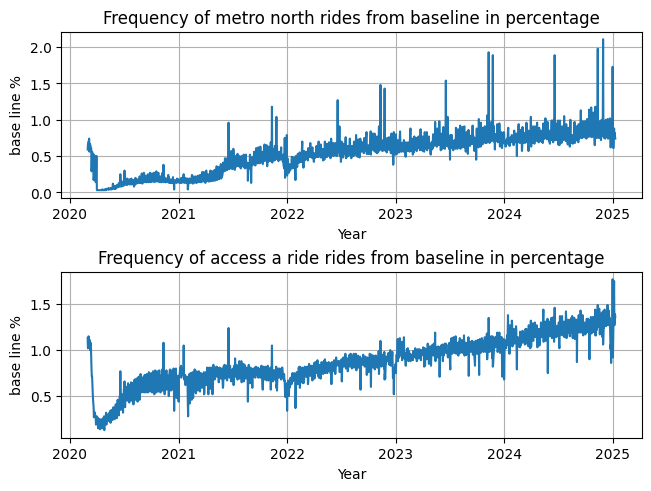

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, layout='constrained')

ax1.plot(df["date"], df["metro_north_of_comparable_pre_pandemic_day"])
ax2.plot(df["date"], df["access_a_ride_of_comparable_pre_pandemic_day"])

ax1.set_title("Frequency of metro north rides from baseline in percentage")
ax2.set_title("Frequency of access a ride rides from baseline in percentage")

ax1.set_xlabel("Year")
ax2.set_xlabel("Year")

ax1.set_ylabel("base line %")
ax2.set_ylabel("base line %")

ax1.grid()
ax2.grid()

plt.show()
